<h1 style="text-align: center; color: #FFD700;">Método de Monte Carlo mediante Cadenas de Markov (MCMC)</h1>


# Formulación del problema

Se desea generar observaciones de una distribución bidimensional cuya función es:

$$
f(x_1,x_2)
=
C\exp\left[
-\frac{x_1^2x_2^2+x_1^2+x_2^2-8x_1-8x_2}{2}
\right]
$$

donde $C$ es una constante de normalización.

El objetivo es **simular valores de $(X_1, X_2)$ que sigan esta distribución** y, a partir de ellos, aproximar numéricamente características de la distribución.

Como la función contiene una forma complicada y no es sencillo generar directamente observaciones de ella, se emplea el método de **Monte Carlo mediante cadenas de Markov (MCMC)**.

El procedimiento es:

1. **Caminata aleatoria:** se propone un nuevo punto a partir del punto actual,

$$ X^* = X^{(t)} + \varepsilon, $$

donde $\varepsilon$ es una perturbación aleatoria. De esta manera, se genera una **caminata aleatoria** por el espacio de posibles valores de $(x_1, x_2)$.

2. **Algoritmo de Metrópolis:** cada punto propuesto $X^*$ se compara con el punto actual mediante la probabilidad de aceptación

$$ \alpha = \min \left( 1, \frac{f(X^*)}{f(X^{(t)})} \right). $$

Si el nuevo punto tiene mayor densidad, se acepta; si tiene menor densidad, se acepta con una probabilidad $\alpha$. Así se construye una **cadena de Markov** cuya distribución estacionaria es $f(x_1, x_2)$.

3. **Monte Carlo:** después de generar un número suficientemente grande de observaciones de la cadena, estas se utilizan como una muestra simulada para aproximar cantidades de interés mediante promedios,

$$ E[h(X)] \approx \frac{1}{N} \sum_{i=1}^{N} h(X^{(i)}). $$

# Simulación por el Método Metropolis
Usando el algoritmo Metropolis - Hastings para simular la función:

$$f(x_1, x_2) = C \exp\left( - \frac{x_1^2 x_2^2 + x_1^2 + x_2^2 - 8x_1 - 8x_2}{2} \right)$$

Definimos

$$ g(x_1, x_2) = \exp \left( -\frac{x_1^2 x_2^2 + x_1^2 + x_2^2 - 8x_1 - 8x_2}{2} \right), $$

Nos queda 

$$ f(x_1, x_2) = C \, g(x_1, x_2). $$

### Cálculo de $C$

Como $f$ debe ser una densidad de probabilidad,

$$ \int_{-\infty}^{\infty} \int_{-\infty}^{\infty} f(x_1, x_2) \, dx_1 dx_2 = 1. $$

Por tanto,

$$ C = \frac{1}{\int_{-\infty}^{\infty} \int_{-\infty}^{\infty} g(x_1, x_2) \, dx_1 dx_2}. $$

Agrupando los términos que contienen $x_1$,

$$ x_1^2 x_2^2 + x_1^2 - 8x_1 + x_2^2 - 8x_2 $$

$$ (x_2^2 + 1)x_1^2 - 8x_1 + x_2^2 - 8x_2. $$

La integral respecto a $x_1$ resulta

$$ \int_{-\infty}^{\infty} g(x_1, x_2) \, dx_1 = \sqrt{\frac{2\pi}{x_2^2 + 1}} \exp \left( \frac{16}{x_2^2 + 1} - \frac{x_2^2 - 8x_2}{2} \right). $$

Así

$$ C^{-1} = \int_{-\infty}^{\infty} \sqrt{\frac{2\pi}{x_2^2 + 1}} \exp \left( \frac{16}{x_2^2 + 1} - \frac{x_2^2 - 8x_2}{2} \right) dx_2. $$

Esta última integral se evalúa numéricamente y permite obtener $C$.

### Metropolis-Hastings

Se inicia en un punto

$$ X^{(0)} = (x_1^{(0)}, x_2^{(0)}). $$

En cada iteración se propone un nuevo punto mediante

$$ \boldsymbol{Y} = \boldsymbol{X}^{(t)} + \boldsymbol{\varepsilon}, $$

$$ \boldsymbol{\varepsilon} \sim N(0, \sigma^2 I). $$

Por lo tanto,

$$ Y_1 = x_1^{(t)} + \varepsilon_1, \quad Y_2 = x_2^{(t)} + \varepsilon_2. $$

Como la distribución propuesta es simétrica,

$$ q(\boldsymbol{Y} \mid \boldsymbol{X}) = q(\boldsymbol{X} \mid \boldsymbol{Y}), $$

la probabilidad de aceptación se reduce a

$$ \alpha(\boldsymbol{X}, \boldsymbol{Y}) = \min \left\{ 1, \frac{f(\boldsymbol{Y})}{f(\boldsymbol{X})} \right\}. $$

Sustituyendo la función,

$$ \alpha = \min \left\{ 1, \frac{C \, g(Y_1, Y_2)}{C \, g(x_1^{(t)}, x_2^{(t)})} \right\}. $$

La constante $C$ se cancela:

$$ \boxed{\alpha = \min \left\{ 1, \frac{g(Y_1, Y_2)}{g(x_1^{(t)}, x_2^{(t)})} \right\}.} $$

Es decir,

$$ \boxed{\alpha = \min \left\{ 1, \exp \left[ -\frac{Y_1^2 Y_2^2 + Y_1^2 + Y_2^2 - 8Y_1 - 8Y_2}{2} + \frac{(x_1^{(t)})^2 (x_2^{(t)})^2 + (x_1^{(t)})^2 + (x_2^{(t)})^2 - 8x_1^{(t)} - 8x_2^{(t)}}{2} \right] \right\}.} $$

Después se genera

$$ U \sim U(0,1), \quad \text{si } U \le \alpha, $$

se acepta la propuesta:

$$ X^{(t+1)} = Y, \quad \text{si } U > \alpha, $$

se rechaza:

$$ X^{(t+1)} = X^{(t)}. $$

El proceso se repite $N$ veces:

$$ X^{(0)}, X^{(1)}, \dots, X^{(N)}. $$

Después de eliminar las primeras iteraciones como **burn-in**, los puntos restantes

$$ \{(x_1^{(t)}, x_2^{(t)})\} $$

constituyen la muestra simulada de la distribución $f(x_1, x_2)$.

Finalmente, cada punto se representa en la superficie mediante

$$ z = f(x_1, x_2), $$

Integral total = 13525914.142786002
Constante C = 7.393215641054076e-08
Error de integración = 0.010319036608936738

Número de simulaciones: 100000
Tasa de aceptación: 0.30381


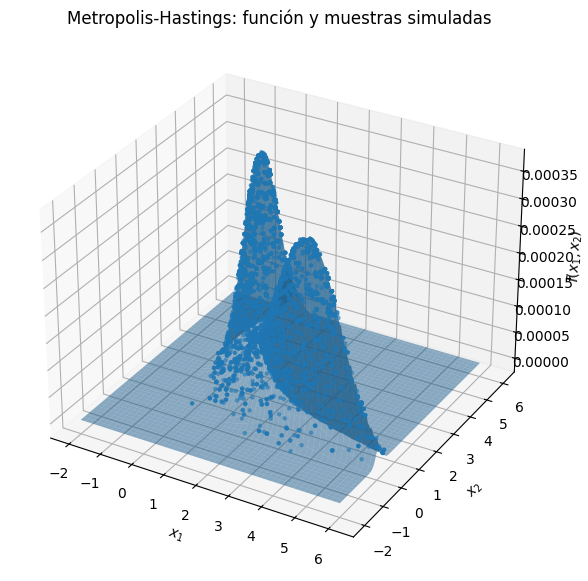

In [17]:
# Se importan las biliotecas 
import numpy as np        # Se utilizará para hacer cálculos numéricos
import matplotlib.pyplot as plt     # Se usa para hacer Graficas 
from scipy.integrate import quad    # Calcula integrales numericamente 

# Se define la funcion sun la constante C
def g(x1, x2):
    return np.exp(
        -(x1**2 * x2**2 + x1**2 + x2**2 - 8*x1 - 8*x2) / 2
    )

# Se calcula el valor de C
def integral_x1(x2):
    A = x2**2 + 1

# Resultado de integrar respecto a X_1
    return (
        np.sqrt(2 * np.pi / A)
        * np.exp(
            16 / A
            - (x2**2 - 8*x2) / 2
        )
    )

# Calcula el valor de la integral total 
integral_total, error = quad(
    integral_x1,
    -np.inf,
    np.inf
)

# Se calcula el valor de C
C = 1 / integral_total

print("Integral total =", integral_total)
print("Constante C =", C)
print("Error de integración =", error)

# Se crea la funcion densidad 
def f(x1, x2):
    return C * g(x1, x2)

# Se define el algoritmo de Metropolis - Hastings
def metropolis_hastings(
    n_iter=100000,
    sigma=1.0,
    x1_inicial=0.0,
    x2_inicial=0.0
):

    # Matriz para guardar las muestras
    muestras = np.zeros((n_iter, 2))

    # Punto inicial
    x_actual = np.array(
        [x1_inicial, x2_inicial],
        dtype=float
    )

    # Densidad del punto inicial
    f_actual = g(
        x_actual[0],
        x_actual[1]
    )

    aceptados = 0

    for i in range(n_iter):

        # Se propone un nuevo punto
        propuesta = x_actual + np.random.normal(
            0,
            sigma,
            size=2
        )

        x1_nuevo = propuesta[0]
        x2_nuevo = propuesta[1]

        # Densidad del nuevo punto
        f_nueva = g(
            x1_nuevo,
            x2_nuevo
        )

        # Se calcula la probabilidad de aceptación
        alpha = min(
            1,
            f_nueva / f_actual
        )

        u = np.random.uniform(0, 1)

        # Aceptar o rechazar
        if u <= alpha:

            x_actual = propuesta
            f_actual = f_nueva

            aceptados += 1

        muestras[i, :] = x_actual

    tasa_aceptacion = aceptados / n_iter

    return muestras, tasa_aceptacion

# Se fija la semilla de los números aleatorios 
np.random.seed(123)

n_iter = 100000

muestras, tasa = metropolis_hastings(
    n_iter=n_iter,
    sigma=1.0,
    x1_inicial=0,
    x2_inicial=0
)

print("\nNúmero de simulaciones:", n_iter)
print("Tasa de aceptación:", tasa)

# Se determina que las primeras 5,000 muestras seran consideradas burn-in
burn_in = 5000

muestras_finales = muestras[burn_in:]

x1_sim = muestras_finales[:, 0]
x2_sim = muestras_finales[:, 1]

# Se crea la malla
x1 = np.linspace(-2, 6, 150)
x2 = np.linspace(-2, 6, 150)

X1, X2 = np.meshgrid(x1, x2)

Z = f(X1, X2)

# Se grafica 
fig = plt.figure(figsize=(10, 7))

ax = fig.add_subplot(
    111,
    projection="3d"
)

ax.plot_surface(
    X1,
    X2,
    Z,
    alpha=0.5
)

# Valores de la función en los puntos simulados
z_sim = f(
    x1_sim,
    x2_sim
)

# Número de puntos que se van a mostrar
n_grafica = min(
    5000,
    len(x1_sim)
)

# Puntos generados por Metropolis-Hastings
ax.scatter(
    x1_sim[:n_grafica],
    x2_sim[:n_grafica],
    z_sim[:n_grafica],
    s=5,
    alpha=0.5
)

ax.set_xlabel("$x_1$")
ax.set_ylabel("$x_2$")
ax.set_zlabel("$f(x_1,x_2)$")

ax.set_title(
    "Metropolis-Hastings: función y muestras simuladas"
)

plt.show()

# Muestras de Metropolis / Caminata aleatoria 

El algoritmo de **Metropolis-Hastings mediante caminata aleatoria** busca generar muestras que sigan esta distribución.

Se inicia en un punto $X_0 = (1, 1)$. En cada iteración se propone un nuevo punto mediante

$$ Y = X_t + Z, \quad Z \sim N(0, \sigma^2 I). $$

Después, se evalúa la función de densidad en el punto actual y en el punto propuesto:

$$ f(X_t), \quad f(Y). $$

Con estos valores se calcula la probabilidad de aceptación:

$$ \alpha = \min \left( 1, \frac{f(Y)}{f(X_t)} \right). $$

Si $f(Y) > f(X_t)$, entonces $\alpha = 1$ y el nuevo punto se acepta. Si $f(Y) < f(X_t)$, el punto puede aceptarse con probabilidad $\alpha$.

Por tanto,

$$ X_{t+1} = \begin{cases} Y, & U < \alpha, \\ X_t, & U \ge \alpha, \end{cases} \quad U \sim U(0,1). $$

La sucesión

$$ X_0, X_1, X_2, \dots, X_N $$

forma una **cadena de Markov**, porque cada nuevo estado depende únicamente del estado anterior.

In [27]:
!pip install pandas


[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


MEDIDAS DE TENDENCIA CENTRAL

Media:   x1 = 1.6831,  x2 = 1.9692
Mediana: x1 = 1.0230,  x2 = 1.7801
Moda:    x1 = 0.15,    x2 = 0.16


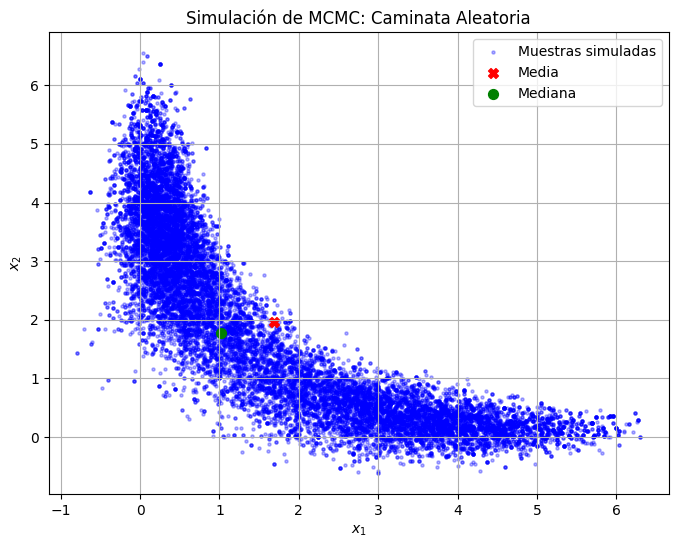

In [31]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd     #se importa para trabajar con datos
from scipy import stats  #Se usa para calcular la moda de las muestras 

# Se define la función de densidad f(x)
def f(x):
    x1, x2 = x[0], x[1]
    C = 1.0 / 20216.335877
    exponent = -0.5 * (x1**2 * x2**2 + x1**2 + x2**2 - 8*x1 - 8*x2)
    return C * np.exp(exponent)

# Se usa simulación de Monte Carlo
N = 20000        # Número de muestras
sigma = 0.5      # Desviación estándar del paso (caminata aleatoria)

samples = np.zeros((N, 2))

X_t = np.array([1.0, 1.0])
samples[0] = X_t

# Algoritmo de Metropolis-Hastings (Caminata Aleatoria)
for t in range(0, N - 1):
    # Usando cadena de Markov se genera una secuencia de puntos en cada paso
    Z = np.random.normal(loc=0.0, scale=sigma, size=2)
    Y = X_t + Z

    # Calcular alpha = min(1, f(Y)/f(X_t))
    f_X = f(X_t)
    f_Y = f(Y)

    if f_X == 0:
        alpha = 1.0
    else:
        alpha = min(1.0, f_Y / f_X)

    # Aceptación / Rechazo
    U = np.random.uniform(0.0, 1.0)
    if U < alpha:
        X_next = Y
    else:
        X_next = X_t

    X_t = X_next
    samples[t + 1] = X_t

# Se calculan las medidas de tendencia central 
media_x1, media_x2 = np.mean(samples, axis=0)

mediana_x1, mediana_x2 = np.median(samples, axis=0)

moda_res = stats.mode(np.round(samples, 2), axis=0, keepdims=True)
moda_x1, moda_x2 = moda_res.mode[0]

print("MEDIDAS DE TENDENCIA CENTRAL\n")
print(f"Media:   x1 = {media_x1:.4f},  x2 = {media_x2:.4f}")
print(f"Mediana: x1 = {mediana_x1:.4f},  x2 = {mediana_x2:.4f}")
print(f"Moda:    x1 = {moda_x1:.2f},    x2 = {moda_x2:.2f}")

plt.figure(figsize=(8, 6))
plt.scatter(samples[:, 0], samples[:, 1], alpha=0.3, s=5, color='blue', label='Muestras simuladas')
plt.scatter([media_x1], [media_x2], color='red', s=50, marker='X', label='Media')
plt.scatter([mediana_x1], [mediana_x2], color='green', s=50, marker='o', label='Mediana')

plt.xlabel('$x_1$')
plt.ylabel('$x_2$')
plt.title('Simulación de MCMC: Caminata Aleatoria')
plt.grid(True)
plt.legend()
plt.show()

# Histogramas de Metropolis

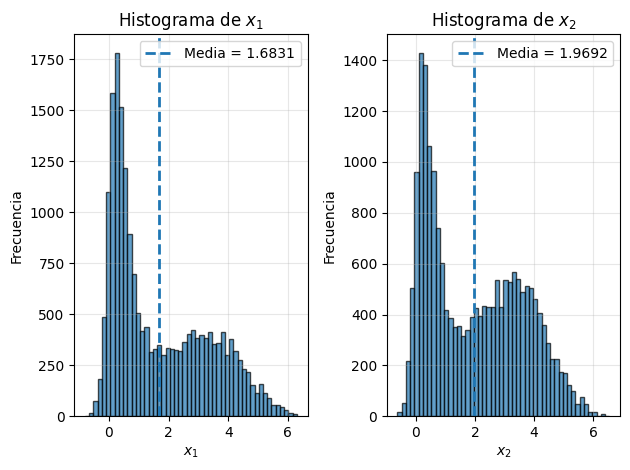

In [32]:
# Histograma de x1
plt.subplot(1, 2, 1)
plt.hist(samples[:, 0], bins=50, alpha=0.7, edgecolor='black')
plt.axvline(media_x1, linestyle='--', linewidth=2,
            label=f'Media = {media_x1:.4f}')

plt.xlabel('$x_1$')
plt.ylabel('Frecuencia')
plt.title('Histograma de $x_1$')
plt.legend()
plt.grid(True, alpha=0.3)

# Histograma de x2
plt.subplot(1, 2, 2)
plt.hist(samples[:, 1], bins=50, alpha=0.7, edgecolor='black')
plt.axvline(media_x2, linestyle='--', linewidth=2,
            label=f'Media = {media_x2:.4f}')

plt.xlabel('$x_2$')
plt.ylabel('Frecuencia')
plt.title('Histograma de $x_2$')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()